In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
from scipy import stats
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from src.data_loader import load_data, remove_nulls,show_duplicates,fill_nulls
from src.analysis import calculate_ema,calculate_sma,calculate_rsi,identify_rsi_signals,calculate_macd,calculate_macd_last_2_years,calculate_bollinger_bands,calculate_volatility,calculate_max_drawdown,calculate_bollinger_bands_2years
from src.plot import plot_bollinger_bands,plot_volatility,plot_price_with_moving_averages,plot_price_with_bollinger_bands



[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\bemnet\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\bemnet\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


# LOAD DATA

In [2]:
df = load_data("../data/raw/Data/NVDA.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,0.199652,0.201027,0.184294,0.184982,497124000
1,2009-01-05,0.203319,0.207904,0.195984,0.197360,705736000
2,2009-01-06,0.210196,0.216156,0.204695,0.209279,657904000
3,2009-01-07,0.197589,0.205382,0.190483,0.205382,870096000
4,2009-01-08,0.192546,0.195067,0.180626,0.195067,1014496000


#  DATA PREPARATION

In [3]:

# 1. Normalize timestamps (convert to timezone-naive)
# convert to datetime
df['Date'] = pd.to_datetime(df['Date'])

# make timezone-naive
df['Date'] = df['Date'].dt.tz_localize(None)

# verify
print(df['Date'].head())

# 2. Ensure columns are correctly typed
df = df.astype({'Open': 'float64', 'High': 'float64', 'Low': 'float64', 'Close': 'float64', 'Volume': 'float64'})

0   2009-01-02
1   2009-01-05
2   2009-01-06
3   2009-01-07
4   2009-01-08
Name: Date, dtype: datetime64[ns]


# HANDLE MISSING VALUES


In [4]:
df = fill_nulls(df)
df = remove_nulls(df)
df.head()

No missing values found.


Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

No missing values found. All 3774 rows kept.


,Date,Close,High,Low,Open,Volume
0,2009-01-02,0.199652,0.201027,0.184294,0.184982,4.971240e+08
1,2009-01-05,0.203319,0.207904,0.195984,0.197360,7.057360e+08
2,2009-01-06,0.210196,0.216156,0.204695,0.209279,6.579040e+08
3,2009-01-07,0.197589,0.205382,0.190483,0.205382,8.700960e+08
4,2009-01-08,0.192546,0.195067,0.180626,0.195067,1.014496e+09


# Technical Indicators with TA-Lib

In [5]:
df = df.sort_values('Date')
df = calculate_sma(
    df,
    column='Close',
    windows=[20,50,100]
)

# calculate EMA
df = calculate_ema(
    df,
    column='Close',
    windows=[20,50,100]
)

# display results
print(df.tail(20))

           Date      Close       High        Low       Open       Volume  \
3754 2023-12-01  46.737453  47.172199  46.159795  46.497597  369317000.0   
3755 2023-12-04  45.483189  46.049856  44.983483  46.049856  437543000.0   
3756 2023-12-05  46.542664  46.576643  45.248311  45.443213  371718000.0   
3757 2023-12-06  45.480198  47.363257  45.389244  47.191342  380590000.0   
3758 2023-12-07  46.572647  46.605632  45.581144  45.677096  350823000.0   
3759 2023-12-08  47.482189  47.717072  46.526667  46.571646  359224000.0   
3760 2023-12-11  46.603630  47.507176  45.807032  47.467199  509728000.0   
3761 2023-12-12  47.633114  47.642108  46.022921  46.022921  372387000.0   
3762 2023-12-13  48.063904  48.569651  47.584145  47.605134  447792000.0   
3763 2023-12-14  48.325771  48.645611  47.398239  48.365752  391232000.0   
3764 2023-12-15  48.865501  49.379244  48.095887  48.169851  479948000.0   
3765 2023-12-18  50.051899  50.407720  49.125365  49.375240  412587000.0   
3766 2023-12

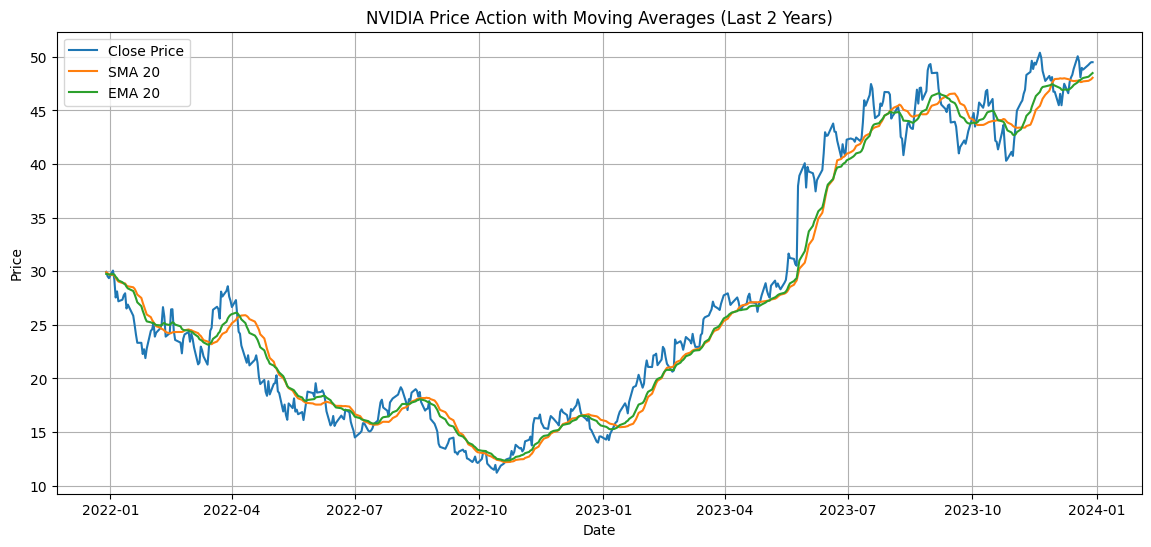

In [8]:
plot_price_with_moving_averages(
    df,
    ticker='NVIDIA'
)

### Moving Average Analysis Summary

- The stock showed a strong long-term upward trend, especially after 2019.
- SMA and EMA closely followed the closing price, confirming the overall market direction.
- EMA reacted more quickly to short-term price fluctuations, while SMA appeared smoother and lagged slightly behind price movements.
- Periods where moving averages moved sharply upward reflected strong bullish momentum and increased market activity.
- Higher volatility was observed between 2020 and 2023, with larger price swings and rapid trend changes.

### Relative Strength Index(RSI)

In [9]:
df = calculate_rsi(
    df,
    column='Close',
    period=14
)

In [10]:



df = identify_rsi_signals(df)

print(
    df[
        ['Date', 'Close', 'RSI', 'Overbought', 'Oversold']
    ].tail(20)
)

           Date      Close        RSI  Overbought  Oversold
3754 2023-12-01  46.737453  49.108327       False     False
3755 2023-12-04  45.483189  43.383994       False     False
3756 2023-12-05  46.542664  48.811816       False     False
3757 2023-12-06  45.480198  44.232155       False     False
3758 2023-12-07  46.572647  49.480676       False     False
3759 2023-12-08  47.482189  53.411954       False     False
3760 2023-12-11  46.603630  49.412115       False     False
3761 2023-12-12  47.633114  53.779964       False     False
3762 2023-12-13  48.063904  55.510993       False     False
3763 2023-12-14  48.325771  56.575647       False     False
3764 2023-12-15  48.865501  58.765888       False     False
3765 2023-12-18  50.051899  63.164028       False     False
3766 2023-12-19  49.579140  60.399383       False     False
3767 2023-12-20  48.086884  52.576776       False     False
3768 2023-12-21  48.965446  56.175512       False     False
3769 2023-12-22  48.805527  55.352119   

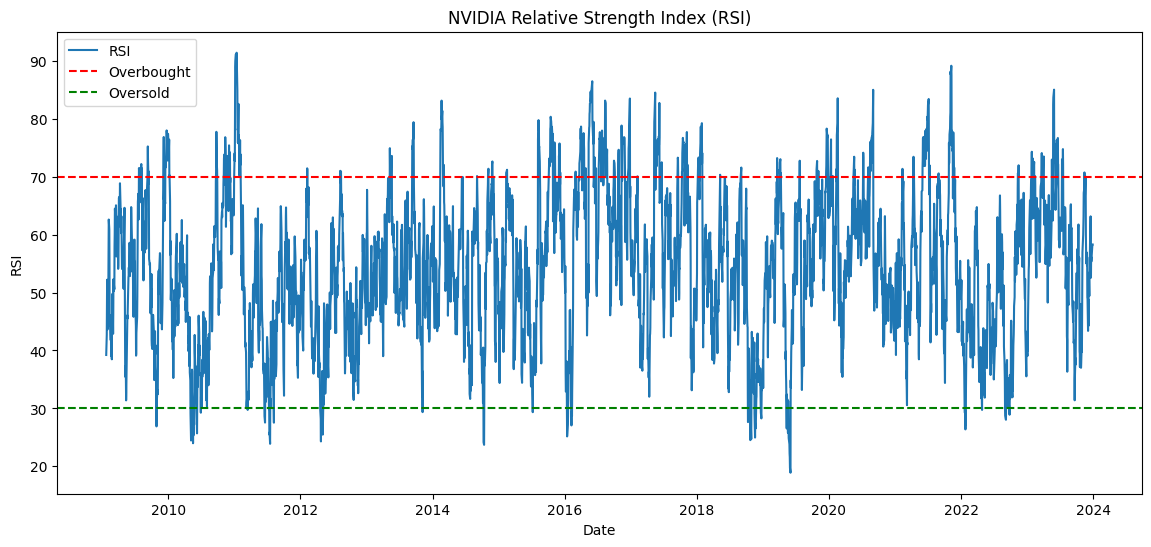

In [12]:
plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['RSI'],
    label='RSI'
)

# overbought line
plt.axhline(
    70,
    color='red',
    linestyle='--',
    label='Overbought'
)

# oversold line
plt.axhline(
    30,
    color='green',
    linestyle='--',
    label='Oversold'
)

plt.xlabel("Date")
plt.ylabel("RSI")

plt.title("NVIDIA Relative Strength Index (RSI)")

plt.legend()

plt.show()

#### RSI Analysis Summary

- The RSI fluctuated frequently between overbought and oversold levels, indicating changing market momentum over time.
- Several periods crossed above the 70 threshold, suggesting temporary overbought conditions and potential price pullbacks.
- Multiple dips below the 30 threshold indicated oversold conditions, which may signal possible buying opportunities or price rebounds.
- Most RSI values remained within the neutral range (30–70), reflecting normal market trading behavior during much of the period.

### MACD (Moving Average Convergence Divergence)


#### MACD For The Last 2 Years

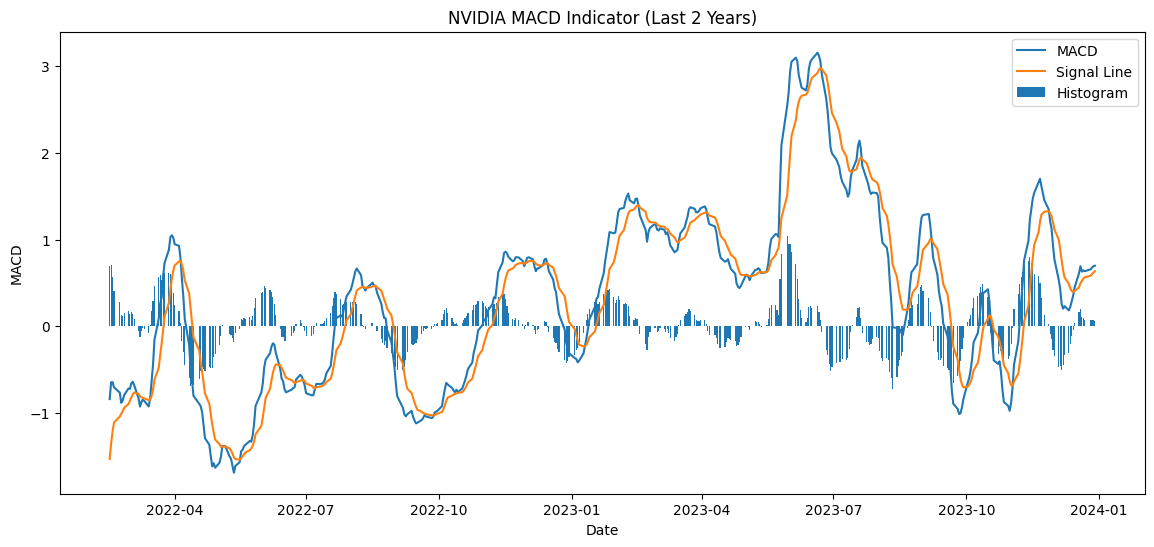

In [15]:
# calculate MACD for last 2 years
macd_df = calculate_macd_last_2_years(df)
plt.figure(figsize=(14,6))

# MACD line
plt.plot(
    macd_df['Date'],
    macd_df['MACD'],
    label='MACD'
)

# Signal line
plt.plot(
    macd_df['Date'],
    macd_df['MACD_Signal'],
    label='Signal Line'
)

# Histogram
plt.bar(
    macd_df['Date'],
    macd_df['MACD_Histogram'],
    label='Histogram'
)

plt.xlabel("Date")
plt.ylabel("MACD")

plt.title("NVIDIA MACD Indicator (Last 2 Years)")

plt.legend()

plt.show()

#### MACD Comparison Summary

- The 2-year MACD chart shows recent market movements more clearly than the full historical chart.
- Several crossings between the MACD and signal line show frequent changes between upward and downward trends.
- Strong upward momentum appeared during parts of 2022 and 2023, while some periods showed clear downward pressure.
- Compared to the previous chart, the shorter timeframe makes recent market trends and momentum changes easier to see.

# Financial Metrics

### Volatility
Measures how much stock prices fluctuate over time using the standard deviation of returns. Higher volatility indicates higher risk.

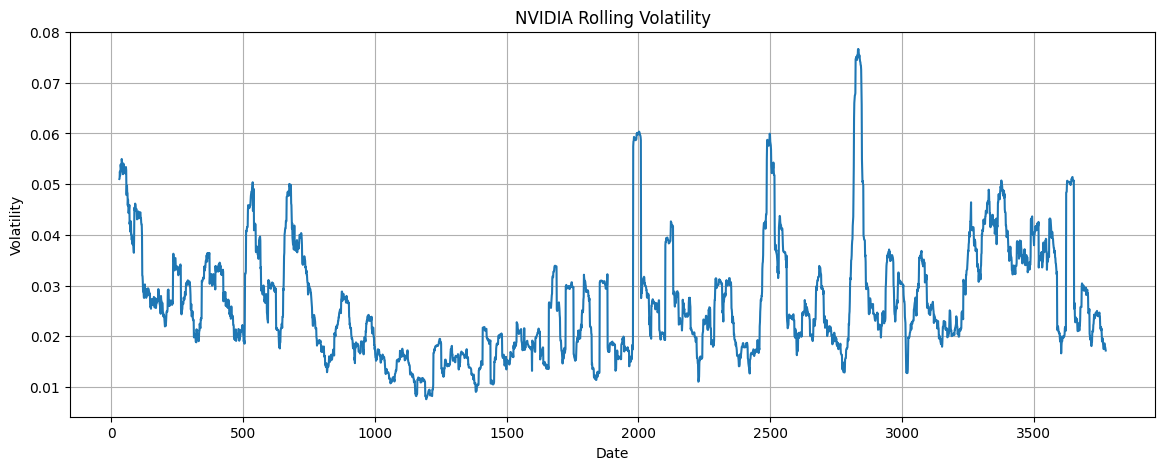

In [16]:
df = calculate_volatility(df)
plot_volatility(df, "NVIDIA")

#### Rolling Volatility Analysis

The rolling volatility analysis for AAPL over the last two years shows generally moderate market fluctuations, with volatility mostly ranging between 0.01 and 0.03. Several short-term spikes were observed, including a major peak above 0.06, indicating periods of increased market uncertainty and strong price movements. Toward the end of the period, volatility declined and stabilized, suggesting reduced market risk and calmer trading conditions.

### Bollinger Bands
A volatility indicator consisting of upper and lower bands around a moving average to identify overbought or oversold conditions.

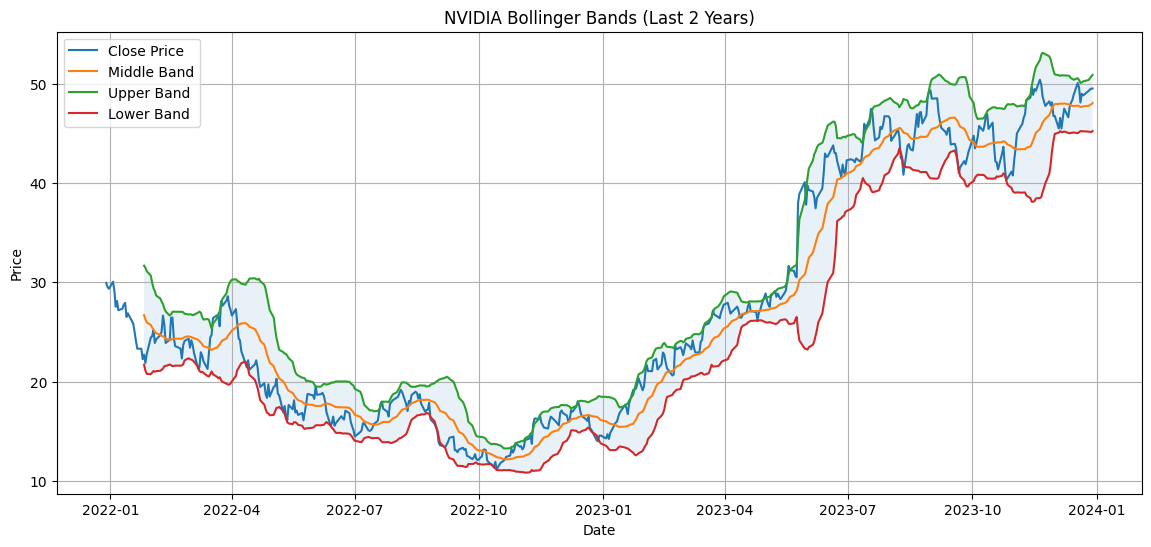

In [18]:
# Calculate Bollinger Bands
df_bollinger = calculate_bollinger_bands_2years(
    df,
    price_column='Close',
    date_column='Date',
    window=20,
    num_std=2
)
# Plot
plot_bollinger_bands(
    df_bollinger,
    ticker='NVIDIA',
    price_column='Close',
    date_column='Date',
    window=20
)

#### Bollinger Bands Analysis

The Bollinger Bands analysis for AAPL over the latest two years shows periods of both high and low market volatility. Wider bands indicate increased price fluctuations and higher market uncertainty, particularly during strong upward and downward price movements. Narrower bands reflect more stable trading periods with lower volatility. The stock price frequently moved near the upper band during bullish trends and near the lower band during market declines, highlighting changing market momentum throughout the period.